# INTARIAN_PEPPER_ROOT — Historical Price Analysis

Round 1 historical data across days **-2, -1, 0**.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import numpy as np
from pathlib import Path

DATA_DIR = Path("../historical_data/round_1")
PRODUCT = "INTARIAN_PEPPER_ROOT"

days = [-2, -1, 0]
frames = []
for d in days:
    df = pd.read_csv(DATA_DIR / f"prices_round_1_day_{d}.csv", sep=";")
    frames.append(df)

raw = pd.concat(frames, ignore_index=True)
df = raw[raw["product"] == PRODUCT].copy()

# Build a continuous x-axis: each day has timestamps 0..999900 (step 100)
TICKS_PER_DAY = 10_000  # max timestamp / 100
df["global_ts"] = (df["day"] - days[0]) * (df["timestamp"].max() + 100) + df["timestamp"]
df = df.sort_values("global_ts").reset_index(drop=True)

# Spread
df["spread"] = df["ask_price_1"] - df["bid_price_1"]

print(f"Rows: {len(df)}")
df[["day", "timestamp", "mid_price", "bid_price_1", "ask_price_1", "spread"]].head(10)

Rows: 30000


,day,timestamp,mid_price,bid_price_1,ask_price_1,spread
0,-2,0,9998.5,9992.0,10005.0,13.0
1,-2,100,10000.5,9995.0,10006.0,11.0
2,-2,200,10001.5,9995.0,10008.0,13.0
3,-2,300,10006.0,NaN,10006.0,NaN
4,-2,400,9999.0,9992.0,10006.0,14.0
5,-2,500,10000.5,9995.0,10006.0,11.0
6,-2,600,10002.0,9995.0,10009.0,14.0
7,-2,700,10000.5,9995.0,10006.0,11.0
8,-2,800,9999.5,9993.0,10006.0,13.0
9,-2,900,10000.5,9995.0,10006.0,11.0


## 1 — Mid Price Over Time

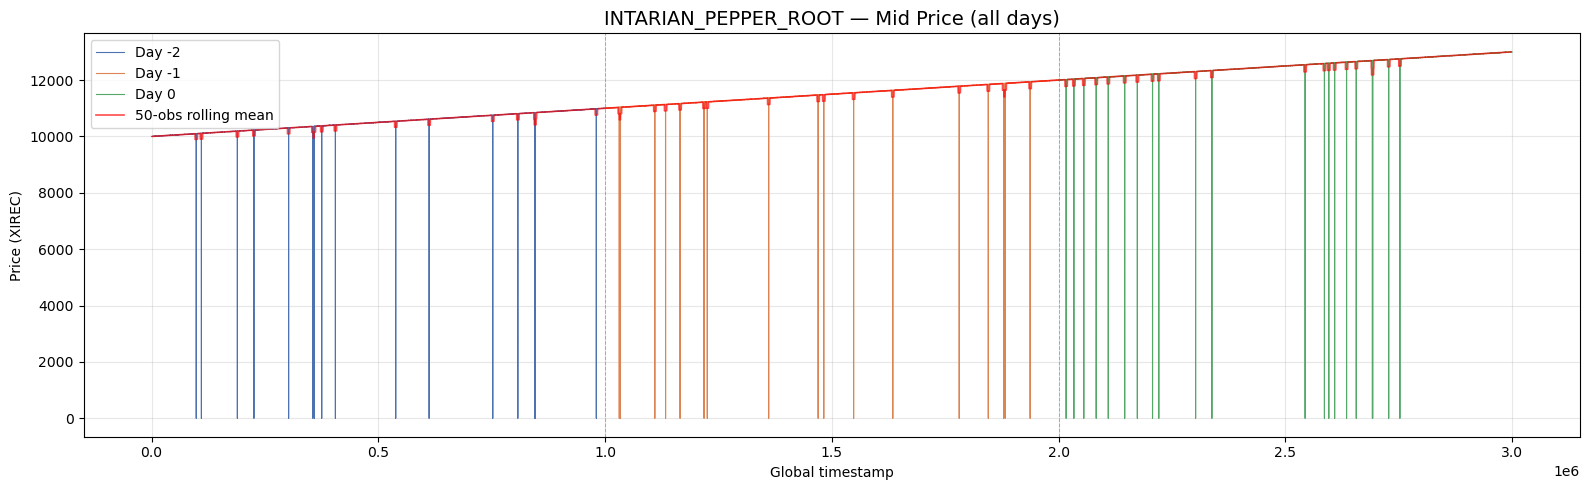

In [2]:
day_colors = {-2: "#4C72B0", -1: "#DD8452", 0: "#55A868"}
day_labels = {-2: "Day -2", -1: "Day -1", 0: "Day 0"}

fig, ax = plt.subplots(figsize=(16, 5))

for d in days:
    sub = df[df["day"] == d]
    ax.plot(sub["global_ts"], sub["mid_price"],
            color=day_colors[d], linewidth=0.8, label=day_labels[d])

# Vertical day-boundary lines
ts_max = df["timestamp"].max() + 100
for i, d in enumerate(days[1:], 1):
    boundary = i * ts_max
    ax.axvline(boundary, color="grey", linestyle="--", linewidth=0.7, alpha=0.6)

# Rolling mean (window = 50 observations ≈ 5000 ts)
df["mid_rolling"] = df["mid_price"].rolling(50, center=True).mean()
ax.plot(df["global_ts"], df["mid_rolling"],
        color="red", linewidth=1.2, linestyle="-", alpha=0.7, label="50-obs rolling mean")

ax.set_title(f"{PRODUCT} — Mid Price (all days)", fontsize=14)
ax.set_xlabel("Global timestamp")
ax.set_ylabel("Price (XIREC)")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 2 — Bid / Ask Prices & Spread

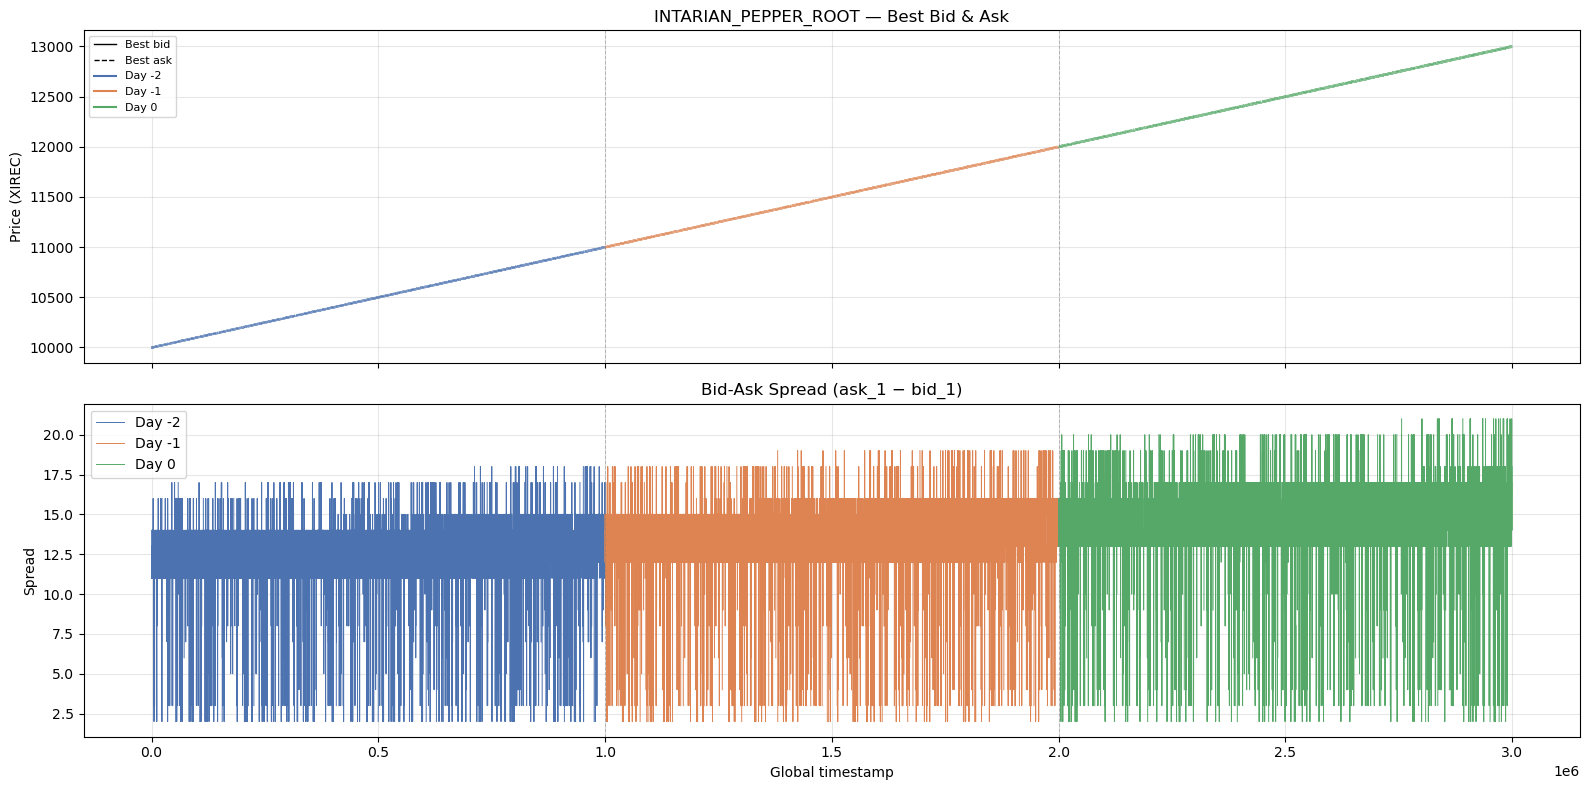

In [3]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(16, 8), sharex=True)

for d in days:
    sub = df[df["day"] == d]
    ax1.plot(sub["global_ts"], sub["bid_price_1"], color=day_colors[d],
             linewidth=0.7, alpha=0.7)
    ax1.plot(sub["global_ts"], sub["ask_price_1"], color=day_colors[d],
             linewidth=0.7, alpha=0.7, linestyle="--")
    ax2.plot(sub["global_ts"], sub["spread"], color=day_colors[d],
             linewidth=0.7, label=day_labels[d])

# Day boundaries
for i in range(1, len(days)):
    boundary = i * ts_max
    ax1.axvline(boundary, color="grey", linestyle="--", linewidth=0.7, alpha=0.5)
    ax2.axvline(boundary, color="grey", linestyle="--", linewidth=0.7, alpha=0.5)

# Legend proxy for solid/dashed
from matplotlib.lines import Line2D
proxy = [
    Line2D([0], [0], color="k", lw=1, label="Best bid"),
    Line2D([0], [0], color="k", lw=1, linestyle="--", label="Best ask"),
] + [Line2D([0], [0], color=day_colors[d], lw=1.5, label=day_labels[d]) for d in days]
ax1.legend(handles=proxy, fontsize=8)

ax1.set_title(f"{PRODUCT} — Best Bid & Ask")
ax1.set_ylabel("Price (XIREC)")
ax1.grid(True, alpha=0.3)

ax2.set_title("Bid-Ask Spread (ask_1 − bid_1)")
ax2.set_ylabel("Spread")
ax2.set_xlabel("Global timestamp")
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 3 — Mid Price Distribution per Day

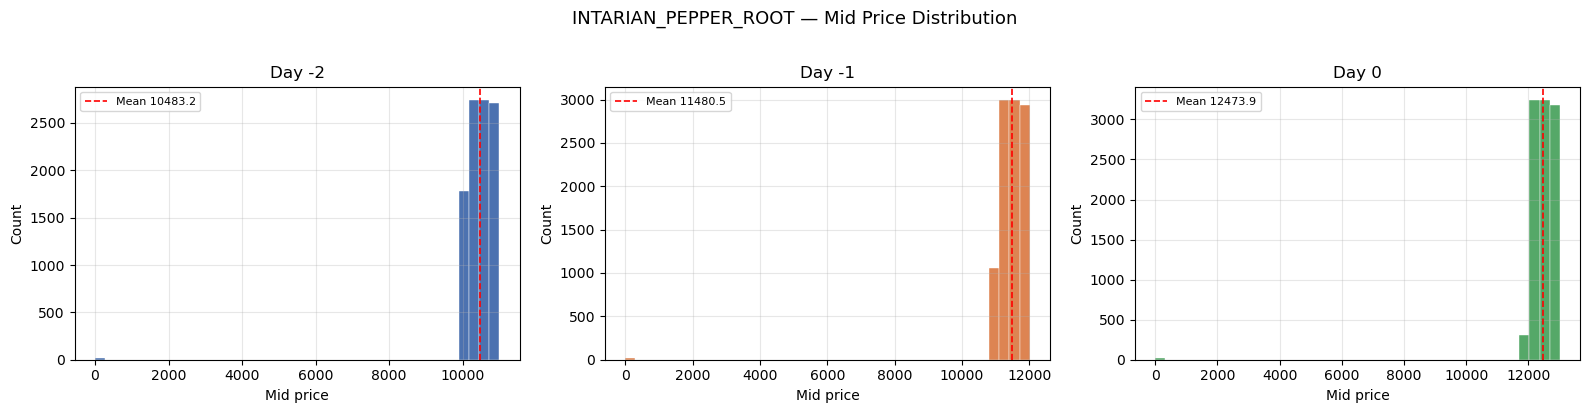

,mean,std,min,max
day,,,,
-2,10483.16,509.28,0.0,11003.0
-1,11480.48,554.67,0.0,12006.0
0,12473.92,640.83,0.0,13007.0


In [4]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4), sharey=False)

for ax, d in zip(axes, days):
    sub = df[df["day"] == d]["mid_price"].dropna()
    ax.hist(sub, bins=40, color=day_colors[d], edgecolor="white", linewidth=0.3)
    ax.axvline(sub.mean(), color="red", linestyle="--", linewidth=1.2, label=f"Mean {sub.mean():.1f}")
    ax.set_title(f"{day_labels[d]}")
    ax.set_xlabel("Mid price")
    ax.set_ylabel("Count")
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)

fig.suptitle(f"{PRODUCT} — Mid Price Distribution", fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

# Summary stats
df.groupby("day")["mid_price"].agg(["mean", "std", "min", "max"]).round(2)

## 4 — Order Book Depth (Best 3 Levels)

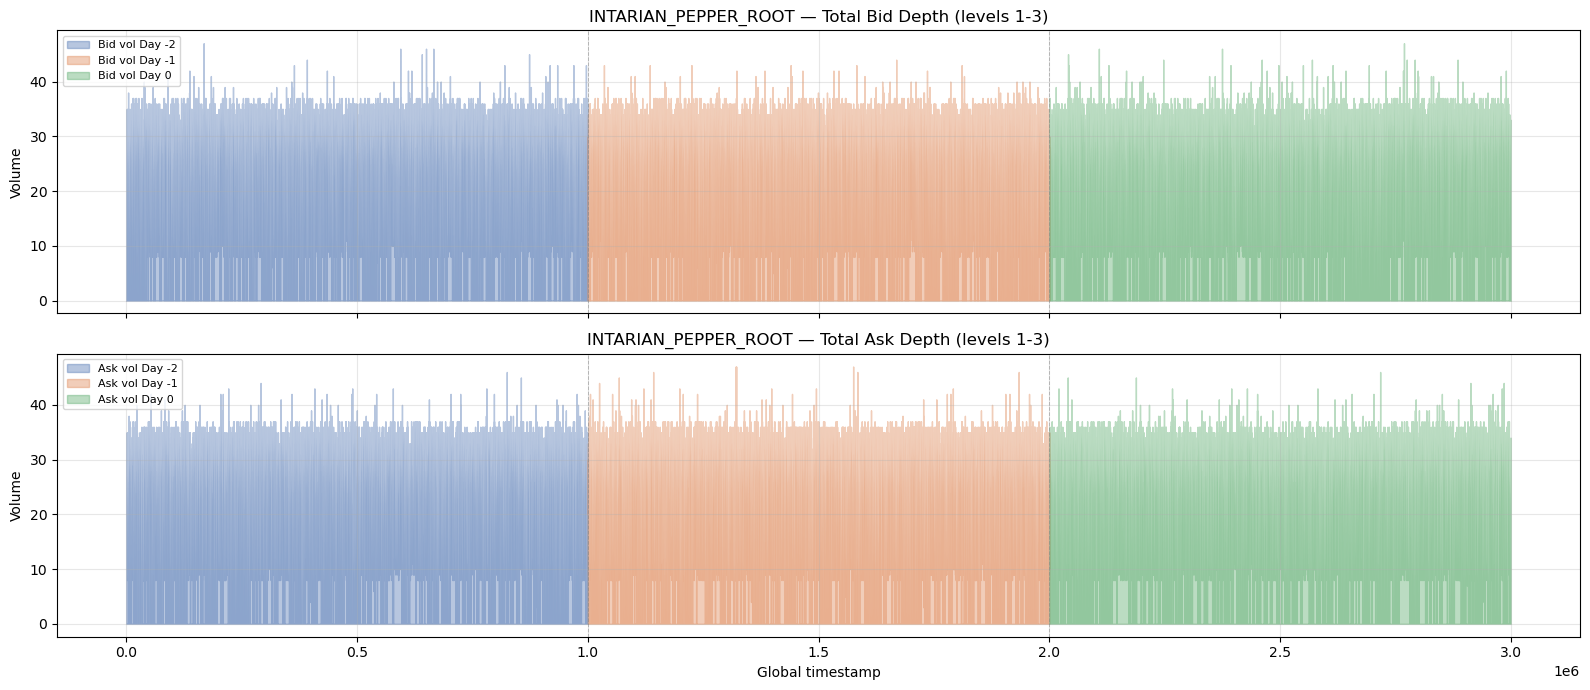

In [5]:
# Total bid and ask volume across all 3 levels
df["total_bid_vol"] = df[["bid_volume_1", "bid_volume_2", "bid_volume_3"]].fillna(0).sum(axis=1)
df["total_ask_vol"] = df[["ask_volume_1", "ask_volume_2", "ask_volume_3"]].fillna(0).abs().sum(axis=1)

fig, axes = plt.subplots(2, 1, figsize=(16, 7), sharex=True)

for d in days:
    sub = df[df["day"] == d]
    axes[0].fill_between(sub["global_ts"], sub["total_bid_vol"],
                         alpha=0.4, color=day_colors[d], label=f"Bid vol {day_labels[d]}")
    axes[1].fill_between(sub["global_ts"], sub["total_ask_vol"],
                         alpha=0.4, color=day_colors[d], label=f"Ask vol {day_labels[d]}")

for ax in axes:
    for i in range(1, len(days)):
        ax.axvline(i * ts_max, color="grey", linestyle="--", linewidth=0.7, alpha=0.5)
    ax.grid(True, alpha=0.3)
    ax.legend(fontsize=8)

axes[0].set_title(f"{PRODUCT} — Total Bid Depth (levels 1-3)")
axes[0].set_ylabel("Volume")
axes[1].set_title(f"{PRODUCT} — Total Ask Depth (levels 1-3)")
axes[1].set_ylabel("Volume")
axes[1].set_xlabel("Global timestamp")

plt.tight_layout()
plt.show()

## 5 — Price Returns & Volatility

/Users/pieterrotteveel/miniconda3/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


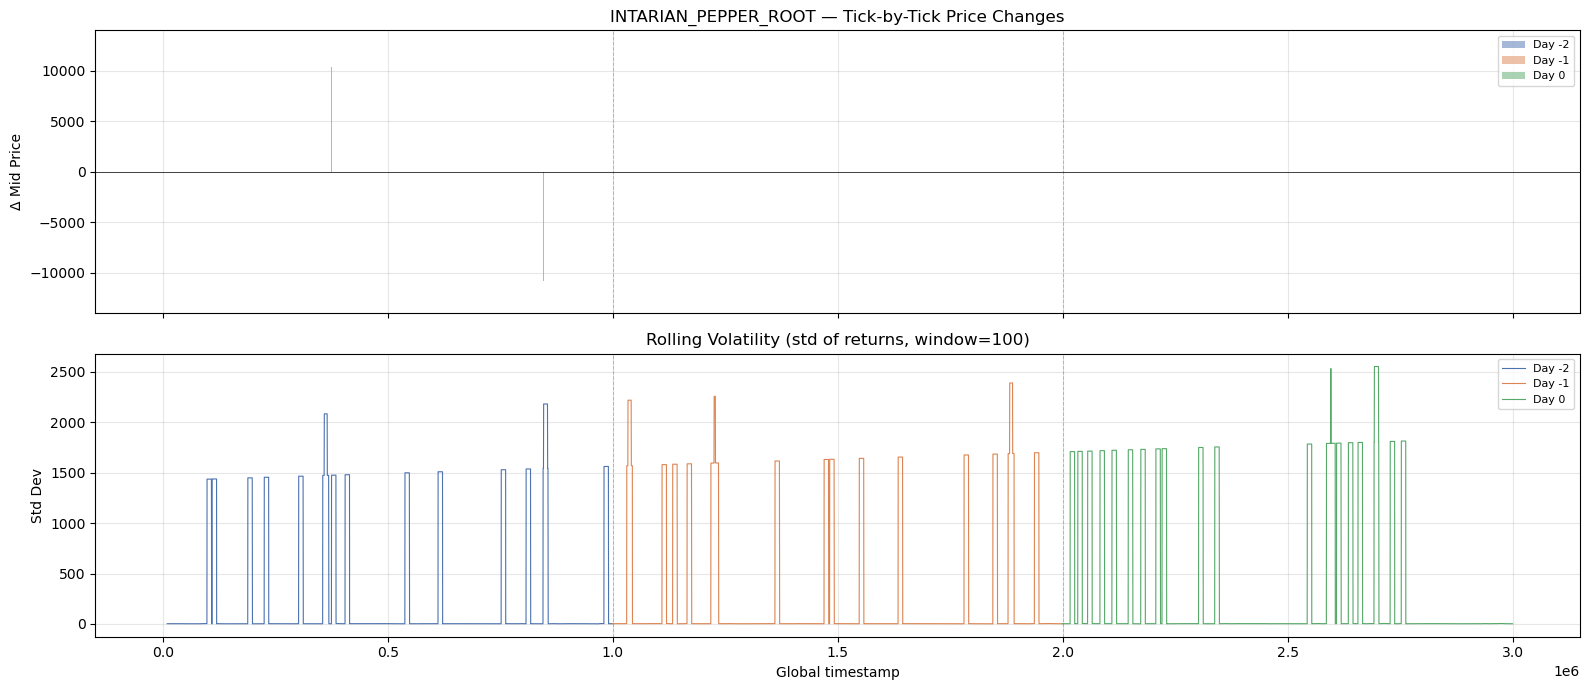

In [6]:
df["returns"] = df["mid_price"].diff()
df["rolling_vol"] = df["returns"].rolling(100).std()

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(16, 7), sharex=True)

for d in days:
    sub = df[df["day"] == d]
    ax1.bar(sub["global_ts"], sub["returns"], width=80,
            color=day_colors[d], alpha=0.5, label=day_labels[d])
    ax2.plot(sub["global_ts"], sub["rolling_vol"],
             color=day_colors[d], linewidth=0.8, label=day_labels[d])

for ax in (ax1, ax2):
    for i in range(1, len(days)):
        ax.axvline(i * ts_max, color="grey", linestyle="--", linewidth=0.7, alpha=0.5)
    ax.grid(True, alpha=0.3)
    ax.legend(fontsize=8)

ax1.axhline(0, color="black", linewidth=0.5)
ax1.set_title(f"{PRODUCT} — Tick-by-Tick Price Changes")
ax1.set_ylabel("Δ Mid Price")

ax2.set_title("Rolling Volatility (std of returns, window=100)")
ax2.set_ylabel("Std Dev")
ax2.set_xlabel("Global timestamp")

plt.tight_layout()
plt.show()